---
title: "Get Started with TabPFN 3.5"
description: "Get started with TabPFN 3.5 and compare its predictive quality and inference speed against TabFM, TabPFN v3 and Tuned XGBoost"
icon: "chart-simple"
cookbookTags:
  - classification
  - benchmark
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
featured: true
---

TabPFN-3.5 is our latest SOTA model (as of date of writing: September 2026). This model is now the default via both open-source `tabpfn` and via the client `tabpfn-client`.

The model family ships with:
- **TabPFN-3.5 (base):** which is what we're using in this notebook. Available both via the open-source package and the client.
- **TabPFN-3.5-Fast:** currently in alpha, this is the one to use when latency is important, and is available both with the open-source and client.
- **TabPFN-3.5-Plus:** available only via the client, this one adds enhanced processing to extract signal from text-rich datasets
- **TabPFN-3.5-Thinking:** also available only via the client, this one improves performance by spending more compute

In this getting started cookbook, we compare TabPFN-3.5 with TabPFN-3, TabFM, default XGBoost, and XGBoost given 10 minutes of cross-validation tuning. We compare them on the OpenML Taiwanese Bankruptcy dataset: 6,819 rows, 94 features, and its official 4,546/2,273 train/test split.

> Given the nature of the topics covered in this example, some cells take a few minutes to run

We use the ROC AUC as classification metric and tune XGBoost with five-fold cross-validation, followed by a full training-set refit. We define latency as the median time for `fit` plus `predict_proba` over three repetitions after an untimed warm-up fit and prediction.

TabPFN 3.5 and TabPFN v3 run through the TabPFN API via `tabpfn-client`, so their latency includes the network round trip. TabFM runs on your local GPU, and XGBoost uses CPU on the same machine. Their timings depend on that hardware and are not directly comparable to API server compute times.

## Client setup

We use TabPFN 3.5 through `tabpfn-client`. Create an API key on the [TabPFN platform](https://platform.priorlabs.ai/account/api-keys) and set the `TABPFN_TOKEN` environment variable before starting Jupyter. On Colab, you can store it as a secret named `TABPFN_TOKEN` using the key icon in the sidebar. An existing cached login also works.

The comparison needs a GPU for TabFM and takes at least 10 minutes because of the XGBoost tuning budget.

In [1]:
%pip install -q tabpfn-client openml xgboost scikit-learn matplotlib pandas "tabfm[pytorch]" safetensors


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import tabpfn_client

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not os.environ.get("TABPFN_TOKEN"):
    from google.colab import userdata

    try:
        token = userdata.get("TABPFN_TOKEN")
    except userdata.SecretNotFoundError:
        token = None
    if token:
        os.environ["TABPFN_TOKEN"] = token

if os.environ.get("TABPFN_TOKEN"):
    tabpfn_client.set_access_token(os.environ["TABPFN_TOKEN"])

tabpfn_client.init()

## Imports and configuration

We fix a single random seed for every model. `TabPFNClassifier` comes from `tabpfn_client`, so TabPFN runs on the API and nothing has to be downloaded. `torch` is only needed for TabFM, which we run locally.

In [3]:
import gc
import math
import random
import statistics
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import openml
import pandas as pd
import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier

from tabpfn_client import TabPFNClassifier

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"TabFM device: {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'}")

TabFM device: NVIDIA L4


## Load the dataset

First, let's load the Taiwanese Bankruptcy dataset from OpenML (task 363706). We use the task's official train/test split so the numbers are reproducible, and label-encode the target so every model sees integer classes.

In [4]:
task = openml.tasks.get_task(363706, download_data=True)
dataset = task.get_dataset()
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
train_idx, test_idx = task.get_train_test_split_indices()

y = LabelEncoder().fit_transform(y.astype(str))
X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]

print(f"{dataset.name}: {len(X_train)} train / {len(X_test)} test rows, {X.shape[1]} features")
X_train.head()

taiwanese_bankruptcy_prediction: 4546 train / 2273 test rows, 94 features


,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,Continuous_Interest_Rate_After_Tax,...,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability
0,0.549115,0.599160,0.603726,0.611460,0.611460,0.998706,0.797676,0.809586,0.304575,0.781889,...,0,0.828796,0.000265,0.623685,0.611456,0.842685,0.279671,0.026800,0.565199,0.029632
1,0.573490,0.645552,0.625890,0.664041,0.664048,0.999455,0.798080,0.809908,0.303715,0.782192,...,0,0.859901,0.004345,0.624214,0.664038,0.843226,0.275245,0.026791,0.565158,0.181966
2,0.398918,0.440362,0.438782,0.598430,0.598430,0.998690,0.796952,0.808904,0.303343,0.781130,...,0,0.730118,0.000842,0.623282,0.598425,0.811333,0.330911,0.026729,0.564845,0.011953
3,0.561254,0.606574,0.600353,0.616700,0.616721,0.999171,0.797696,0.809534,0.303637,0.781809,...,0,0.838246,0.001380,0.624070,0.616697,0.842677,0.277050,0.026795,0.565178,0.051092
4,0.573392,0.551570,0.598587,0.610458,0.610458,0.999168,0.797627,0.809436,0.303522,0.781702,...,0,0.808521,0.005057,0.623346,0.610454,0.840657,0.275136,0.026804,0.565218,0.222929


## Measuring quality and speed

Every model is scored the same way. `metrics` computes ROC AUC (our primary metric), log loss and accuracy from predicted probabilities. `timed_fit_predict` measures the median time for `fit` plus `predict_proba` over three repetitions. An untimed fit and prediction first warm up each model, including loading TabFM and TabPFN. Each measured repetition then refits on the full training set and predicts the full test set. For the locally run TabFM we synchronize CUDA around each repetition so the timer includes completed GPU work. XGBoost preprocessing and hyperparameter search are outside this timer; its final fit is included.

In [5]:
def metrics(y_true: np.ndarray, proba: np.ndarray) -> dict[str, float]:
    proba = np.clip(np.asarray(proba, dtype=float), 1e-12, None)
    proba /= proba.sum(axis=1, keepdims=True)
    if proba.shape[1] == 2:
        auc = roc_auc_score(y_true, proba[:, 1])
    else:
        auc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    return {
        "roc_auc": float(auc),
        "log_loss": float(log_loss(y_true, proba, labels=np.arange(proba.shape[1]))),
        "accuracy": float(accuracy_score(y_true, proba.argmax(axis=1))),
    }


def sync_cuda() -> None:
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def timed_fit_predict(model: Any, X_train: Any, y_train: Any, X_test: Any, *, repeats: int):
    model.fit(X_train, y_train)
    proba = np.asarray(model.predict_proba(X_test))  # warm-up, excluded from timing
    sync_cuda()
    samples = []
    for _ in range(repeats):
        sync_cuda()
        start = time.perf_counter()
        model.fit(X_train, y_train)
        proba = np.asarray(model.predict_proba(X_test))
        sync_cuda()
        samples.append(time.perf_counter() - start)
    latency = statistics.median(samples)
    return proba, {"fit_predict_ms": 1000 * latency, "rows_per_second": len(X_test) / latency}

## Run the models

TabPFN and TabFM need no dataset-specific hyperparameter search.

### TabPFN 3.5 and TabPFN v3

Both TabPFN versions go through the same `TabPFNClassifier` API. `model_path` picks the model: `"v3.5_default"` for the new model and `"v3_default"` for the previous one. We tell the model which columns are categorical; everything else stays at the defaults. The timed fit-and-predict calls include API request and network time after an untimed warm-up. The service may cache repeated uploads; these are warm API wall times, not server-only compute times.

In [6]:
def categorical_indices(X: pd.DataFrame) -> list[int]:
    categorical = X.select_dtypes(include=["category", "object", "string", "bool"]).columns
    return [X.columns.get_loc(column) for column in categorical]


def run_tabpfn(model_path: str, X_train, X_test, y_train, y_test, *, repeats: int):
    model = TabPFNClassifier(
        model_path=model_path,
        random_state=SEED,
        categorical_features_indices=categorical_indices(X_train),
    )
    proba, speed = timed_fit_predict(model, X_train, y_train, X_test, repeats=repeats)
    return {**metrics(y_test, proba), **speed}


scores = {
    "TabPFN 3.5": run_tabpfn("v3.5_default", X_train, X_test, y_train, y_test, repeats=3),
    "TabPFN v3": run_tabpfn("v3_default", X_train, X_test, y_train, y_test, repeats=3),
}
scores

Train set already exists, skipping upload.


Test set already exists, skipping upload.


Train set already exists, skipping upload.


Test set already exists, skipping upload.


Train set already exists, skipping upload.


...

Train set already exists, skipping upload.


Test set already exists, skipping upload.


Train set already exists, skipping upload.


Test set already exists, skipping upload.


{'TabPFN 3.5': {'roc_auc': 0.9571295143212952,
  'log_loss': 0.07593335189399324,
  'accuracy': 0.9714034315882094,
  'fit_predict_ms': 8692.384107999998,
  'rows_per_second': 261.49327638525017},
 'TabPFN v3': {'roc_auc': 0.9506351183063512,
  'log_loss': 0.07754246421259653,
  'accuracy': 0.9722833260008799,
  'fit_predict_ms': 3973.461168,
  'rows_per_second': 572.0453538857888}}

### TabFM

TabFM is Google's tabular foundation model. Its PyTorch loader downloads the pretrained weights, and `TabFMClassifier` provides the same fit-and-predict interface. We use its default settings, with no dataset-specific tuning.

In [7]:
from tabfm import TabFMClassifier, tabfm_v1_0_0_pytorch as tabfm_v1_0_0


def run_tabfm(X_train, X_test, y_train, y_test, *, repeats: int):
    base_model = tabfm_v1_0_0.load(model_type="classification", device=DEVICE)
    model = TabFMClassifier(model=base_model, random_state=SEED)
    proba, speed = timed_fit_predict(model, X_train, y_train, X_test, repeats=repeats)
    result = {**metrics(y_test, proba), **speed}

    del model, base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


scores["TabFM"] = run_tabfm(X_train, X_test, y_train, y_test, repeats=3)
scores["TabFM"]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 224.94it/s]

Loading weights from local directory


{'roc_auc': 0.9506911581569116,
 'log_loss': 0.077403400559889,
 'accuracy': 0.9714034315882094,
 'fit_predict_ms': 167442.931702,
 'rows_per_second': 13.574774264256687}

### XGBoost, out of the box

XGBoost is shown both out of the box and after 10 minutes of tuning. Unlike the foundation models, XGBoost needs explicit preprocessing: we median-impute numerical columns and mode-impute plus ordinal-encode categorical ones. The default run keeps the predictive hyperparameters at their defaults; we fix the random seed and use histogram trees with the available CPU threads.

In [8]:
def xgb_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    categorical = list(X.select_dtypes(include=["category", "object", "string", "bool"]).columns)
    numerical = [column for column in X.columns if column not in categorical]
    transformers = []
    if numerical:
        transformers.append(("num", SimpleImputer(strategy="median"), numerical))
    if categorical:
        cat_pipe = make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        )
        transformers.append(("cat", cat_pipe, categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)


def xgb_model(params: dict, n_classes: int, *, rounds: int | None = None) -> XGBClassifier:
    common = {
        "random_state": SEED,
        "n_jobs": int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1)),
        "tree_method": "hist",
        "verbosity": 0,
    }
    if rounds is not None:
        common["n_estimators"] = rounds
    if n_classes > 2:
        common.update(objective="multi:softprob", num_class=n_classes)
    else:
        common["objective"] = "binary:logistic"
    return XGBClassifier(**common, **params)


def run_xgb_default(X_train, X_test, y_train, y_test, *, repeats: int):
    prep = xgb_preprocessor(X_train)
    Xt, Xv = prep.fit_transform(X_train), prep.transform(X_test)
    model = xgb_model({}, len(np.unique(y_train)))
    proba, speed = timed_fit_predict(model, Xt, y_train, Xv, repeats=repeats)
    return {**metrics(y_test, proba), **speed}


scores["XGBoost · default"] = run_xgb_default(X_train, X_test, y_train, y_test, repeats=3)
scores["XGBoost · default"]

{'roc_auc': 0.9404794520547944,
 'log_loss': 0.10945151584370365,
 'accuracy': 0.970523537175539,
 'fit_predict_ms': 224.2936479999571,
 'rows_per_second': 10134.036430672502}

### XGBoost, tuned for 10 minutes

To give XGBoost a fair shot we run a random search over its main hyperparameters (log-uniform ranges for learning rate and regularization) with five-fold stratified cross-validation and early stopping on each fold. The first candidate is a sensible hand-picked configuration; the rest are sampled at random until the time budget runs out. The best configuration by mean CV ROC AUC is refit on the full training set with the median number of boosting rounds found during CV.

This cell takes about 10 minutes to run.

In [9]:
def sample_xgb_params(rng: random.Random) -> dict:
    def log_uniform(low: float, high: float) -> float:
        return math.exp(rng.uniform(math.log(low), math.log(high)))

    return {
        "learning_rate": log_uniform(0.01, 0.3),
        "max_depth": rng.randint(2, 10),
        "min_child_weight": log_uniform(0.1, 20),
        "subsample": rng.uniform(0.55, 1.0),
        "colsample_bytree": rng.uniform(0.55, 1.0),
        "gamma": log_uniform(1e-8, 5),
        "reg_alpha": log_uniform(1e-8, 10),
        "reg_lambda": log_uniform(1e-3, 100),
        "max_bin": rng.choice([128, 256, 512]),
    }



Each candidate is evaluated on the same five training folds. We retain complete trials, choose the best mean ROC AUC, and refit on all training rows.


In [10]:
def run_xgb_tuned(X_train, X_test, y_train, y_test, *, budget_seconds: float, repeats: int):
    rng = random.Random(SEED)
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    n_classes = len(np.unique(y_train))
    deadline = time.perf_counter() + budget_seconds
    trials = []

    candidates = [{
        "learning_rate": 0.05, "max_depth": 6, "min_child_weight": 1.0,
        "subsample": 0.9, "colsample_bytree": 0.9, "gamma": 0.0,
        "reg_alpha": 0.0, "reg_lambda": 1.0, "max_bin": 256,
    }]

    trial_index = 0
    while time.perf_counter() < deadline:
        params = candidates[trial_index] if trial_index < len(candidates) else sample_xgb_params(rng)
        fold_scores, best_rounds, complete = [], [], True
        for train_idx, val_idx in folds.split(X_train, y_train):
            if fold_scores and time.perf_counter() >= deadline:
                complete = False
                break
            X_fold, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            prep = xgb_preprocessor(X_fold)
            Xt, Xv = prep.fit_transform(X_fold), prep.transform(X_val)
            model = xgb_model(
                {**params, "early_stopping_rounds": 50, "eval_metric": "logloss"}, n_classes, rounds=4000
            )
            model.fit(Xt, y_train[train_idx], eval_set=[(Xv, y_train[val_idx])], verbose=False)
            fold_scores.append(metrics(y_train[val_idx], model.predict_proba(Xv))["roc_auc"])
            best_rounds.append(int(getattr(model, "best_iteration", 3999)) + 1)
        if complete and len(fold_scores) == 5:
            trials.append({"params": params, "score": float(np.mean(fold_scores)), "rounds": int(np.median(best_rounds))})
        trial_index += 1

    if not trials:
        raise RuntimeError("No complete CV trial. Increase budget_seconds and rerun.")

    best = max(trials, key=lambda trial: trial["score"])
    print(f"{len(trials)} complete trials; best CV ROC AUC = {best['score']:.4f}")

    prep = xgb_preprocessor(X_train)
    Xt, Xv = prep.fit_transform(X_train), prep.transform(X_test)
    model = xgb_model(best["params"], n_classes, rounds=best["rounds"])
    proba, speed = timed_fit_predict(model, Xt, y_train, Xv, repeats=repeats)
    return {**metrics(y_test, proba), **speed}


scores["XGBoost · 10-min CV"] = run_xgb_tuned(X_train, X_test, y_train, y_test, budget_seconds=600, repeats=3)
scores["XGBoost · 10-min CV"]

225 complete trials; best CV ROC AUC = 0.9436


{'roc_auc': 0.9498879202988793,
 'log_loss': 0.07882943421758269,
 'accuracy': 0.9718433787945446,
 'fit_predict_ms': 202.00806999991983,
 'rows_per_second': 11252.025723531253}

## Quality and speed

With all five models scored, we put the results side by side.

In [11]:
results = (
    pd.DataFrame(scores).T
    .rename(columns={"roc_auc": "ROC AUC", "accuracy": "Accuracy",
                     "log_loss": "Log loss", "fit_predict_ms": "Fit + predict (ms)"})
    [["ROC AUC", "Accuracy", "Log loss", "Fit + predict (ms)"]]
    .astype(float)
)
results.round({"ROC AUC": 4, "Accuracy": 4, "Log loss": 4, "Fit + predict (ms)": 2})

,ROC AUC,Accuracy,Log loss,Fit + predict (ms)
TabPFN 3.5,0.9571,0.9714,0.0759,8692.38
TabPFN v3,0.9506,0.9723,0.0775,3973.46
TabFM,0.9507,0.9714,0.0774,167442.93
XGBoost · default,0.9405,0.9705,0.1095,224.29
XGBoost · 10-min CV,0.9499,0.9718,0.0788,202.01


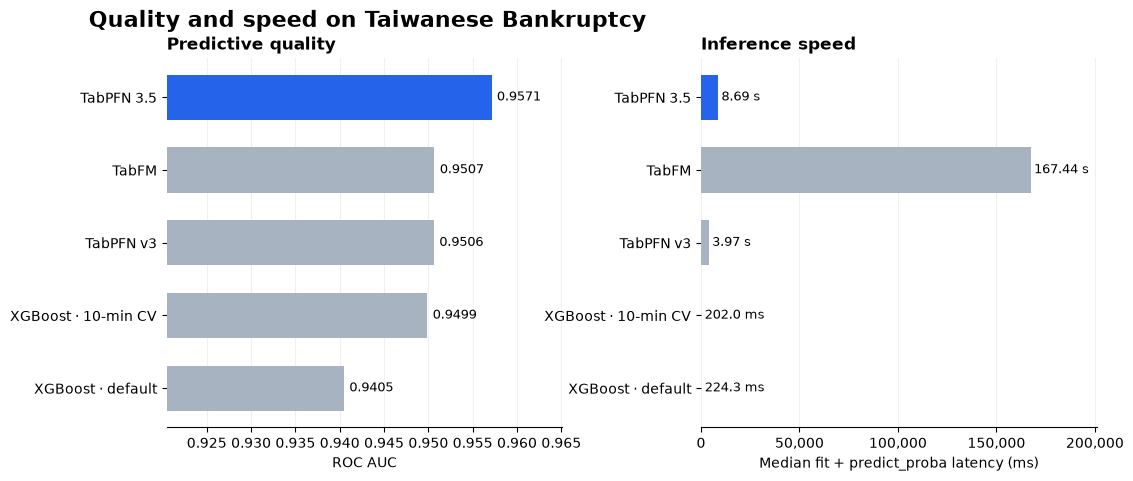

In [12]:
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

order = results["ROC AUC"].sort_values().index
colors = ["#A8B3C2" if name != "TabPFN 3.5" else "#2563EB" for name in order]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"wspace": 0.35})

auc = results.loc[order, "ROC AUC"]
axes[0].barh(order, auc, color=colors, height=0.62)
axes[0].set_xlim(max(0.5, auc.min() - 0.02), min(1, auc.max() + 0.008))
axes[0].set_title("Predictive quality", loc="left", weight="bold")
axes[0].set_xlabel("ROC AUC")
for y, value in enumerate(auc):
    axes[0].text(value + 0.0006, y, f"{value:.4f}", va="center", fontsize=9)

latency = results.loc[order, "Fit + predict (ms)"]
axes[1].barh(order, latency, color=colors, height=0.62)
axes[1].set_title("Inference speed", loc="left", weight="bold")
axes[1].set_xlabel("Median fit + predict_proba latency (ms)")
for y, value in enumerate(latency):
    label = f"{value / 1000:.2f} s" if value >= 1000 else f"{value:.1f} ms"
    axes[1].text(value + 0.01 * latency.max(), y, label, va="center", fontsize=9)

for ax in axes:
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", alpha=0.18)
    ax.set_axisbelow(True)
axes[1].set_xlim(0, latency.max() * 1.2)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.suptitle("Quality and speed on Taiwanese Bankruptcy", x=0.06, ha="left", fontsize=16, weight="bold")
plt.show()

On this split, TabPFN 3.5 has the highest ROC AUC and lowest log loss. XGBoost has much lower fit-plus-predict latency.

ROC AUC measures how well each model ranks bankrupt companies above non-bankrupt ones; higher is better. Compare it with log loss to assess the quality of the predicted probabilities, and with latency to judge the cost of making predictions.

These results describe one dataset and one held-out split. API timings include network overhead, while TabFM timings depend on your GPU. The 10-minute XGBoost search can also complete a different number of trials on different machines. XGBoost timings include the final fit and prediction, but exclude preprocessing and the 10-minute hyperparameter search.
